# EDA Analysis

### Initial settings

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
from pathlib import Path
from src.pipelines import *
from src.analysis import *
from src.utils.data_split.functions import (split_data_by_patient,
                                            create_y_class_report,
                                            export_split_data_to_csv,
                                            binarize_readmitted
                                            )

sns.set(style="darkgrid")  # default style


PATH_DATA = Path("../data/source/diabetic_data.csv")
PATH_DATA_DICT = Path("../data/source/data_dictionary.csv")

### Data loading and pre-processing

In [2]:
# Load data and replace '?' with nan
df_raw = pd.read_csv(PATH_DATA).astype(str).replace('?', np.nan)

# Load data dictionary
df_data_dict = pd.read_csv(PATH_DATA_DICT)

# Get integer / categorical / id feature columns
col_int = df_data_dict.loc[df_data_dict['Type'] == 'Integer']['Variable Name'].tolist()
col_cat = df_data_dict.loc[(df_data_dict['Type'] == 'Categorical') & (df_data_dict['Variable Name'] != 'readmitted')]['Variable Name'].tolist()
col_y   = ['readmitted']

col_drop = []

# Convert numerical columns to integers
df_raw[col_int] = df_raw[col_int].astype(int)

# Binarize the target variable
print('Note: We binarize the target variable `readmitted` by grouping `["No", "<30", ">30"]` into `[0, 1]`, where integer label `0` represents `No` while `["<30", ">30"] are grouped into integer label `1`.')
df_raw = binarize_readmitted(df_raw)
print('\n')

# Split the data
print('Perform data splitting. Note that given we will perform out-of-fold cross-validation, we will use 80-20 train-test split for EDA and data preprocessing, and perform validation split within the training data during cross-validation.')
print('\n')
print('Note: In data splitting. with duplicated patient numbers, the splitting needs to consider the same patient in the same set to prevent hindsight bias.')
print('\n')
X_train, X_train_mini, X_val, X_test, y_train, y_train_mini, y_val, y_test = split_data_by_patient(df_raw, test_size_step_1=0.2, test_size_step_2=0.25)
print('\n')

# Get the remining ID columns (encounter_id)
col_ids = [c for c in X_train.columns if c not in col_int + col_cat + col_y]

Note: We binarize the target variable `readmitted` by grouping `["No", "<30", ">30"]` into `[0, 1]`, where integer label `0` represents `No` while `["<30", ">30"] are grouped into integer label `1`.


Perform data splitting. Note that given we will perform out-of-fold cross-validation, we will use 80-20 train-test split for EDA and data preprocessing, and perform validation split within the training data during cross-validation.


Note: In data splitting. with duplicated patient numbers, the splitting needs to consider the same patient in the same set to prevent hindsight bias.


Patient-grouped data split report
-----
Original data shape: (101766, 50)
X_train shape:      (81300, 48) | y_train shape:      (81300,)
X_train_mini shape: (61081, 48) | y_train_mini shape: (61081,)
X_val shape:        (20219, 48) | y_val shape:        (20219,)
X_test shape:       (20466, 48) | y_test shape:       (20466,)
-----
Train pool rows: 81300 (79.89% of full data)
Train rows:      61081 (60.02% of fu

### Target variable analysis

Target variable analysis


Plot readmitted label counts:


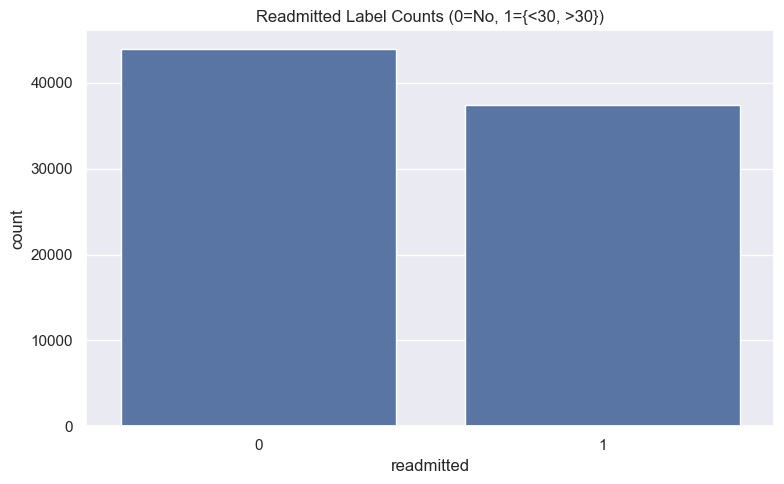



Observation:
- After binarization, the labels in the target variable have similar proportions and do not suffer from data imbalance issues.


Decision:
- No further action.


In [3]:
print('Target variable analysis')
print('\n')

print('Plot readmitted label counts:')
fig = plt.figure(figsize=(8, 5))
plot = sns.barplot(y_train.value_counts().reset_index(), x='readmitted', y='count')
plot.set_title('Readmitted Label Counts (0=No, 1={<30, >30})')
plt.tight_layout()
plt.show()
print('\n')

print('Observation:')
print('- After binarization, the labels in the target variable have similar proportions and do not suffer from data imbalance issues.')
print('\n')

print('Decision:')
print('- No further action.')

### Univariate analysis table

In [4]:
# Get univariate analysis for integer columns
u_int = Univariate(X_train[col_int].reset_index(drop=True), unique_th=0)
eda_u_int = u_int.describe().T

# Get univariate analysis for categorical columns
u_cat = Univariate(X_train[col_cat].reset_index(drop=True), unique_th=1)
eda_u_cat = u_cat.describe().T

print('Categorical data:')
print(eda_u_cat)
print('\n')

print('Numerical data:')
print(eda_u_int)
print('\n')

Categorical data:
                           nobs missing distinct             top_1  \
race                      81300    1807        5         Caucasian   
gender                    81300       0        3            Female   
age                       81300       0       10           [70-80)   
weight                    81300   78728        9          [75-100)   
admission_type_id         81300       0        8                 1   
discharge_disposition_id  81300       0       26                 1   
admission_source_id       81300       0       17                 7   
payer_code                81300   32325       17                MC   
medical_specialty         81300   39817       70  InternalMedicine   
diag_1                    81300      17      693               428   
diag_2                    81300     287      718               276   
diag_3                    81300    1133      764               250   
max_glu_serum             81300   77071        3              Norm   
A1

### Missing data analysis

Missing data analysis


Plot missing percentages:


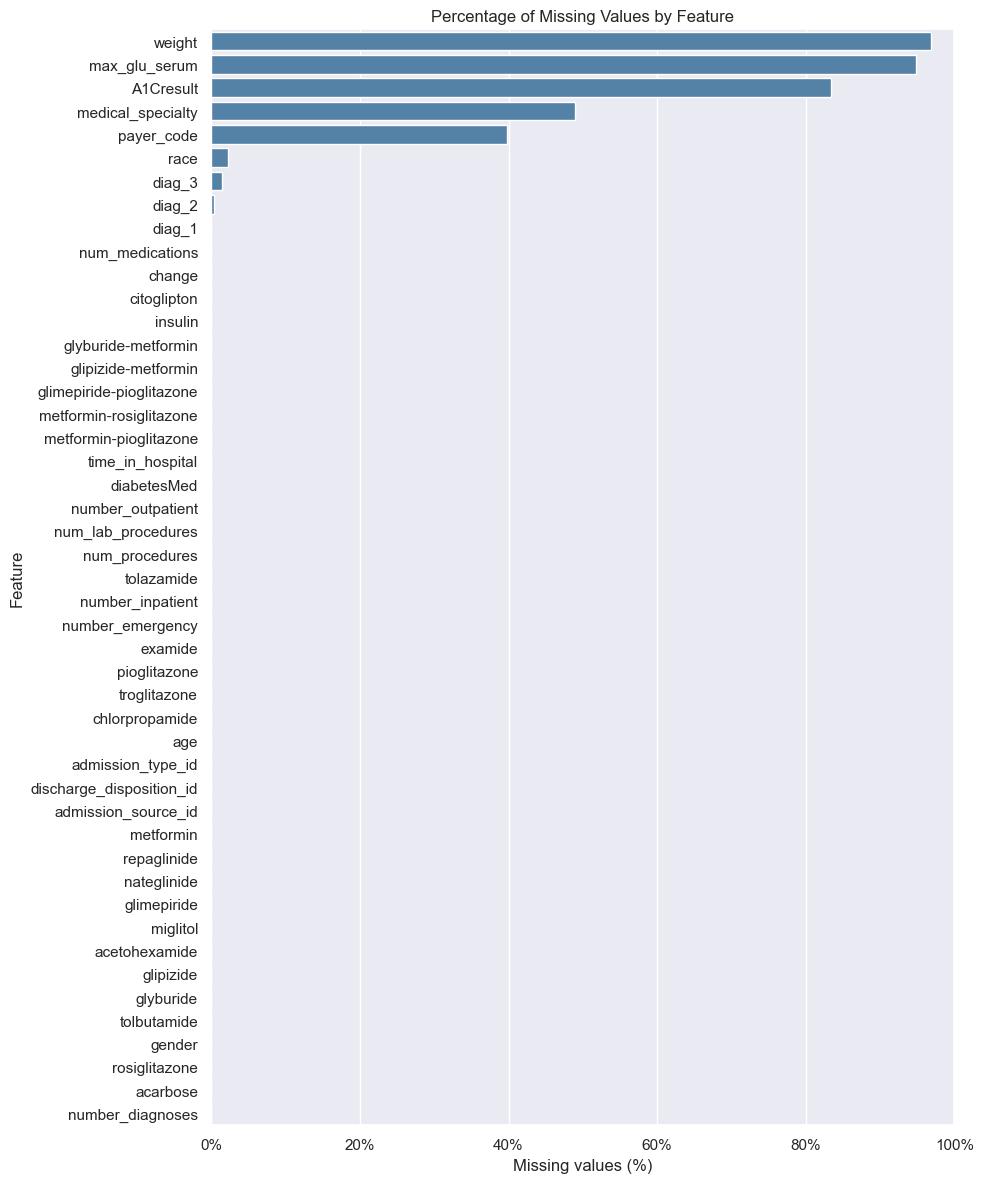



Observation:
- Among the input features, `weight` (0.9684), `max_glu_serum` (0.948), `A1Cresult` (0.8334), `medical_specialty` (0.4898), and `payer_code` (0.3976) contains material proportions of missing values.
- From the data dictionary, we assume `encounter_id`, `patient_nbr`, `weight` and `payer_code` have no implications to the readmission classification.
- Despite the relatively high missing percentages, `max_glu_serum` and `A1Cresult` are tests that reflect blood sugar levels and are associated with diabetes severeness.
- `medical_specialty` may contain symptoms that are related to diabetes.


Decision:
- Drop columns `encounter_id`, `patient_nbr`, `weight` and `payer_code`.
- Keep `medical_specialty`, `max_glu_serum` and `A1Cresult`.


In [5]:
print('Missing data analysis')
print('\n')

df_missing = pd.concat([eda_u_cat[['missing']], eda_u_int[['missing']]], axis=0, ignore_index=False) / X_train.shape[0]

# Plot missing
print('Plot missing percentages:')
plot_df = df_missing.reset_index()
plot_df.columns = ["feature", "missing"]
plot_df = plot_df.sort_values("missing", ascending=False)
plt.figure(figsize=(10, 12))
ax = sns.barplot(
    data=plot_df,
    x="missing",
    y="feature",
    color="steelblue"
)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set(
    xlabel="Missing values (%)",
    ylabel="Feature",
    title="Percentage of Missing Values by Feature"
)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()
print('\n')

print('Observation:')
print(f'- Among the input features, '
      f'`weight` ({df_missing.loc['weight']['missing']:.04}), '
      f'`max_glu_serum` ({df_missing.loc['max_glu_serum']['missing']:.04}), '
      f'`A1Cresult` ({df_missing.loc['A1Cresult']['missing']:.04}), '
      f'`medical_specialty` ({df_missing.loc['medical_specialty']['missing']:.04}), and '
      f'`payer_code` ({df_missing.loc['payer_code']['missing']:.04}) contains material proportions of missing values.')
print('- From the data dictionary, we assume `encounter_id`, `patient_nbr`, `weight` and `payer_code` have no implications to the readmission classification.')
print('- Despite the relatively high missing percentages, `max_glu_serum` and `A1Cresult` are tests that reflect blood sugar levels and are associated with diabetes severeness.')
print('- `medical_specialty` may contain symptoms that are related to diabetes.')
print('\n')

print('Decision:')
print('- Drop columns `encounter_id`, `patient_nbr`, `weight` and `payer_code`.')
print('- Keep `medical_specialty`, `max_glu_serum` and `A1Cresult`.')

# Drop columns
col_drop.extend(['encounter_id', 'patient_nbr', 'weight', 'payer_code'])
col_cat = [c for c in col_cat if c not in col_drop]
col_int = [c for c in col_int if c not in col_drop]
X_train = X_train[col_cat + col_int]
X_test = X_test[col_cat + col_int]
X_val = X_val[col_cat + col_int]

### Cardinality analysis

Cardinality analysis


Plot unique counts and ratios:


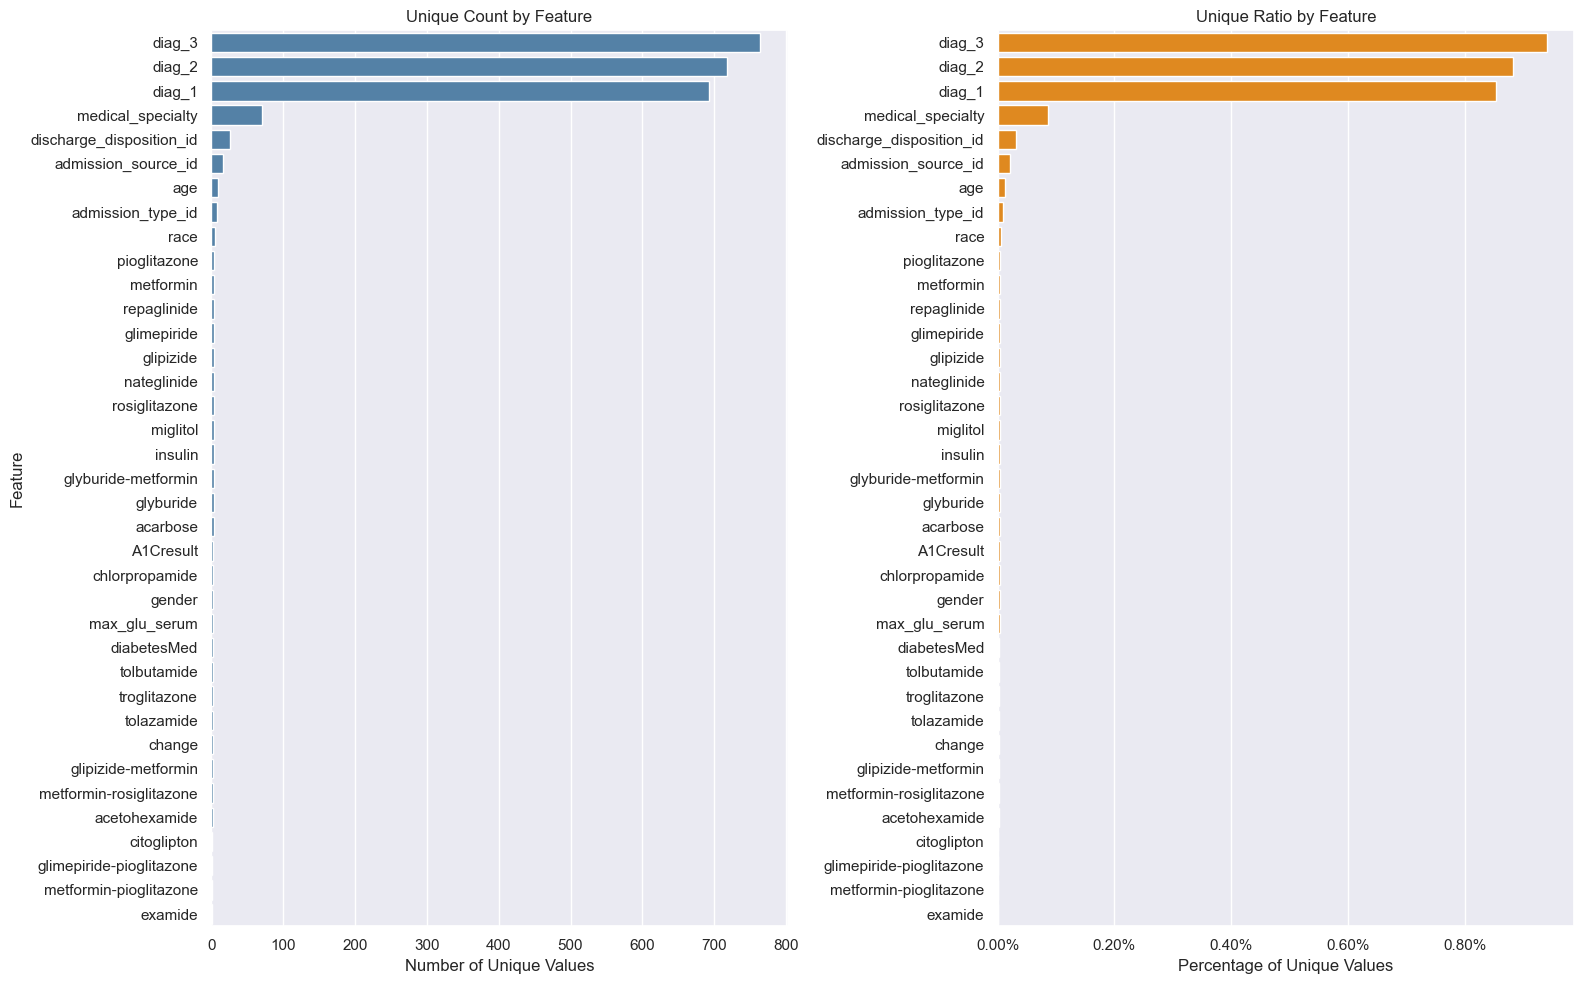



Observation:
- Among the input features, `diag_1` (693), `diag_2` (718), and`diag_3` (764) contain high number of unique values. To mitigate the high cardinality issues, they should be grouped by their corresponding medical interpretations.


Decision:
- Treatment 1: Group `diag_1`, `diag_2`, `diag_3` which are the ICD9 codes by the broader types of diagnosis. Perform one-hot encoding after grouping for parametric models.
- Treatment 2: Convert the origin (no grouping) description of diagnosis into label encoding for non-parametric modelling.
- Treatment 3: Convert the origin (no grouping) description of diagnosis into embeddings for neural network modelling.
- To `max_glu_serum` and `A1Cresult`, as they are immune from cardinality, perform one-hot encoding.




In [6]:

print('Cardinality analysis')
print('\n')

df_unique = eda_u_cat.loc[col_cat][['nobs', 'distinct']]
df_unique['unique_count'] = df_unique['distinct']
df_unique['unique_ratio'] = df_unique['unique_count'] / df_unique['nobs']
df_unique.sort_values('unique_count', ascending=False, inplace=True)
df_unique.index.name = 'feature'
df_unique.reset_index(inplace=True)

# Plot unique counts and ratios
print('Plot unique counts and ratios:')
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 10)
)
sns.barplot(
    data=df_unique.sort_values("unique_count", ascending=False),
    x="unique_count",
    y="feature",
    ax=axes[0],
    color="steelblue"
)
axes[0].set(
    title="Unique Count by Feature",
    xlabel="Number of Unique Values",
    ylabel="Feature"
)
sns.barplot(
    data=df_unique.sort_values("unique_ratio", ascending=False),
    x="unique_ratio",
    y="feature",
    ax=axes[1],
    color="darkorange"
)
axes[1].set(
    title="Unique Ratio by Feature",
    xlabel="Percentage of Unique Values",
    ylabel=""
)
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()
print('\n')

print('Observation:')
print(f'- Among the input features, '
      f'`diag_1` ({df_unique.set_index('feature').loc['diag_1']['unique_count']}), '
      f'`diag_2` ({df_unique.set_index('feature').loc['diag_2']['unique_count']}), and'
      f'`diag_3` ({df_unique.set_index('feature').loc['diag_3']['unique_count']}) '
      f'contain high number of unique values. To mitigate the high cardinality issues, they should be grouped by their corresponding medical interpretations.')
print('\n')

print('Decision:')
print('- Treatment 1: Group `diag_1`, `diag_2`, `diag_3` which are the ICD9 codes by the broader types of diagnosis. Perform one-hot encoding after grouping for parametric models.')
print('- Treatment 2: Convert the origin (no grouping) description of diagnosis into label encoding for non-parametric modelling.')
print('- Treatment 3: Convert the origin (no grouping) description of diagnosis into embeddings for neural network modelling.')
print('- To `max_glu_serum` and `A1Cresult`, as they are immune from cardinality, perform one-hot encoding.')
print('\n')

Plot ICD9 code counts (top 50 codes):


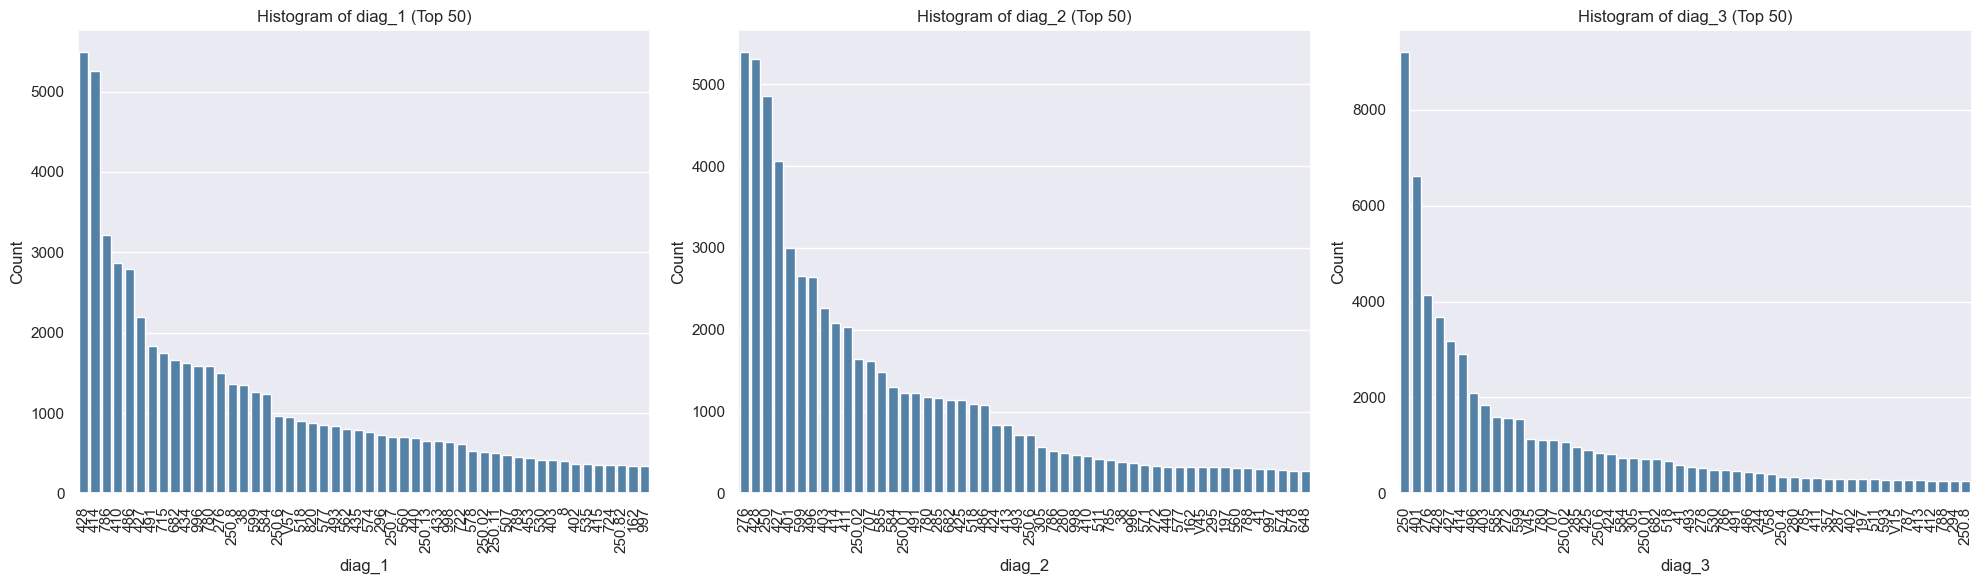

In [7]:
print('Plot ICD9 code counts (top 50 codes):')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col in zip(axes, ['diag_1', 'diag_2', 'diag_3']):
    order = X_train[col].value_counts().index[:50]
    sns.countplot(
        data=X_train,
        x=col,
        ax=ax,
        order=order,
        color="steelblue",
    )
    ax.set(
        title=f"Histogram of {col} (Top 50)",
        xlabel=col,
        ylabel="Count",
    )
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()
print('\n')

Plot grouped ICD9 code category counts:


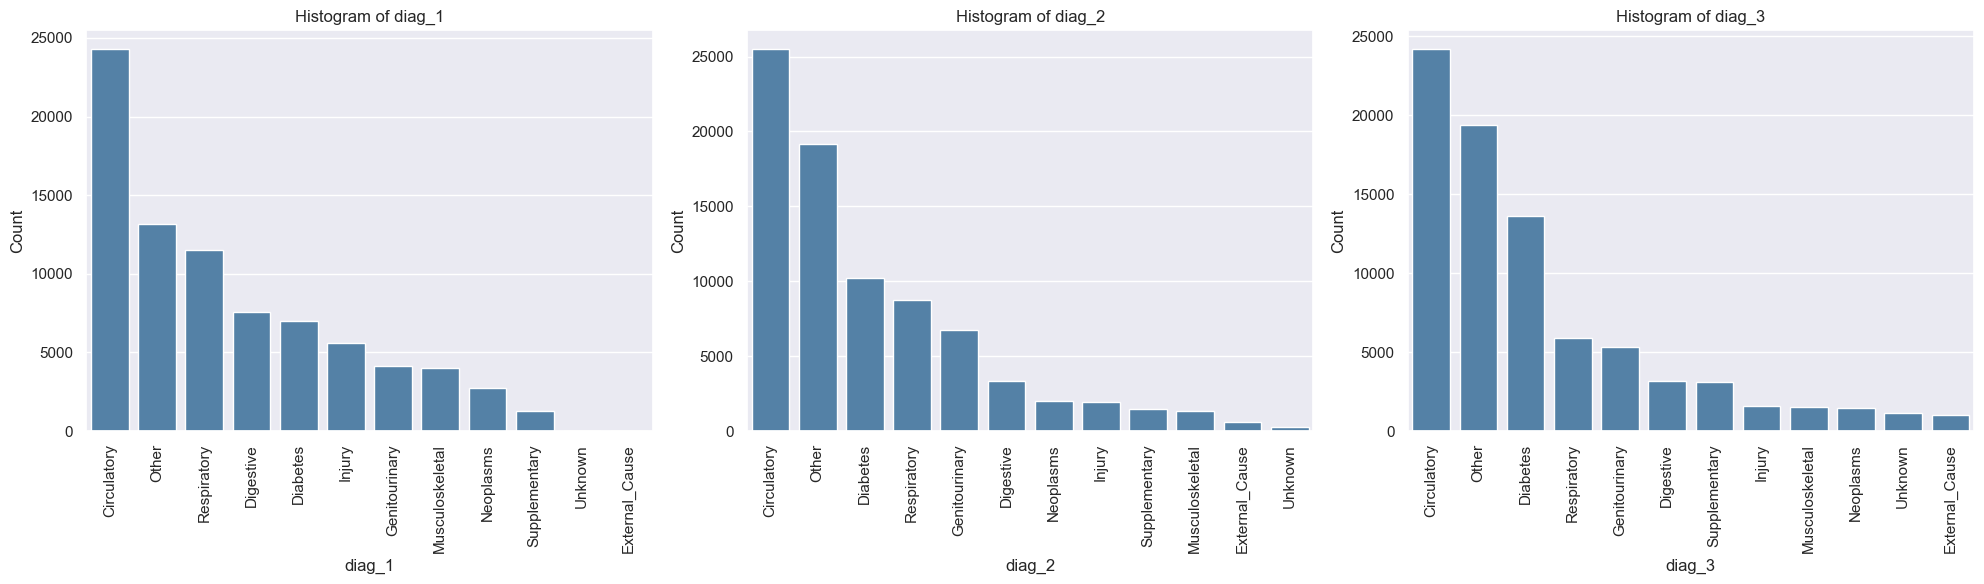

In [8]:
print('Plot grouped ICD9 code category counts:')

X_train_adj = ICD9Grouper().fit_transform(X_train)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col in zip(axes, ['diag_1', 'diag_2', 'diag_3']):
    order = X_train_adj[col].value_counts().index
    sns.countplot(
        data=X_train_adj,
        x=col,
        ax=ax,
        order=order,
        color="steelblue",
    )
    ax.set(
        title=f"Histogram of {col}",
        xlabel=col,
        ylabel="Count",
    )
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()
print('\n')


### Other demographic features (`age` and `race`)

Other demographic features (`age` and `race`)


Plot histograms of `age` and `race`:


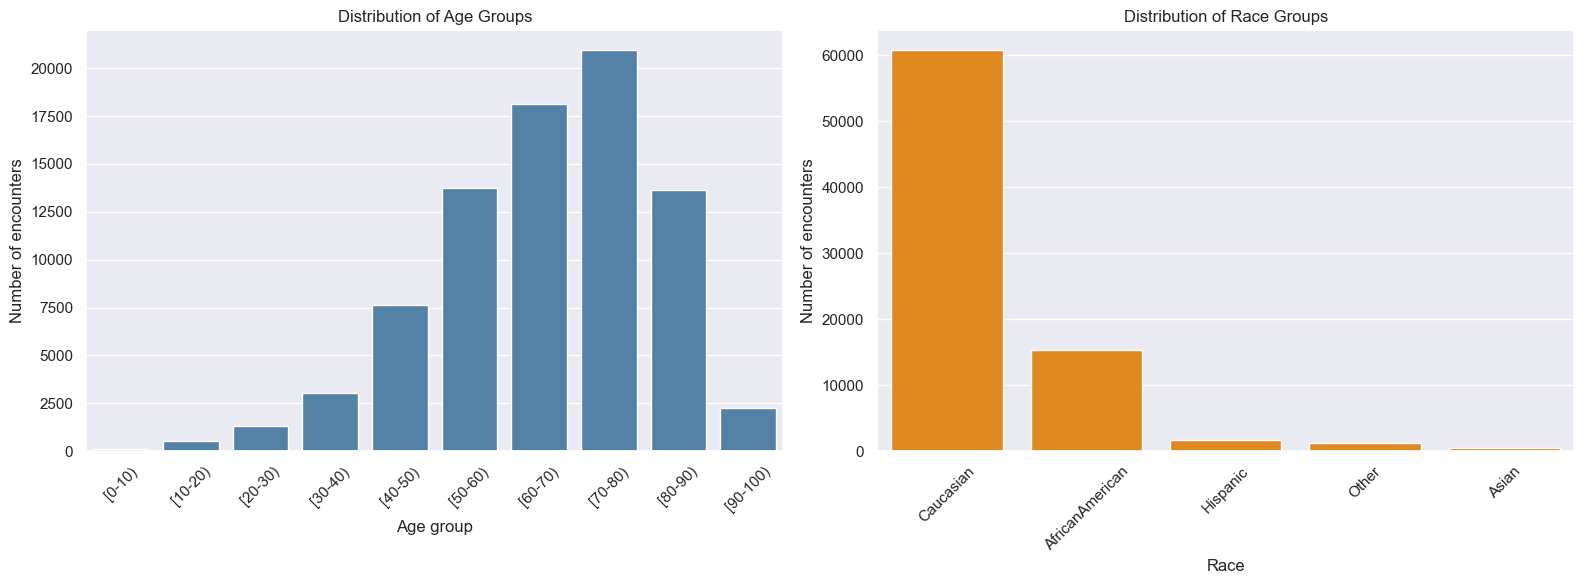



Observation:
- Despite the skewed distribution of age groups and imbalanced labels in races, they do not suffer from any cardinality nor missing data issues.


Decision:
- Perform one-hot encoding directly without any grouping.


In [9]:
print('Other demographic features (`age` and `race`)')
print('\n')

# Plot histogram of `age` and `race`
print('Plot histograms of `age` and `race`:')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

age_order = sorted(X_train["age"].dropna().unique())

sns.countplot(
    data=X_train,
    x="age",
    order=age_order,
    ax=axes[0],
    color="steelblue"
)
axes[0].set(
    title="Distribution of Age Groups",
    xlabel="Age group",
    ylabel="Number of encounters"
)
axes[0].tick_params(axis="x", rotation=45)

race_order = X_train["race"].value_counts().index

sns.countplot(
    data=X_train,
    x="race",
    order=race_order,
    ax=axes[1],
    color="darkorange"
)
axes[1].set(
    title="Distribution of Race Groups",
    xlabel="Race",
    ylabel="Number of encounters"
)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
print('\n')

print('Observation:')
print(f'- Despite the skewed distribution of age groups and imbalanced labels in races, they do not suffer from any cardinality nor missing data issues.')
print('\n')

print('Decision:')
print('- Perform one-hot encoding directly without any grouping.')

### Medical specialty and operations (`medical_specialty`, `discharge_disposition_id`, `admission_type_id`, and `admission_source_id`)

Medical specialty and operations (`medical_specialty`, `discharge_disposition_id`, `admission_type_id`, and `admission_source_id`)


Plot histograms of medical specialties and operations:


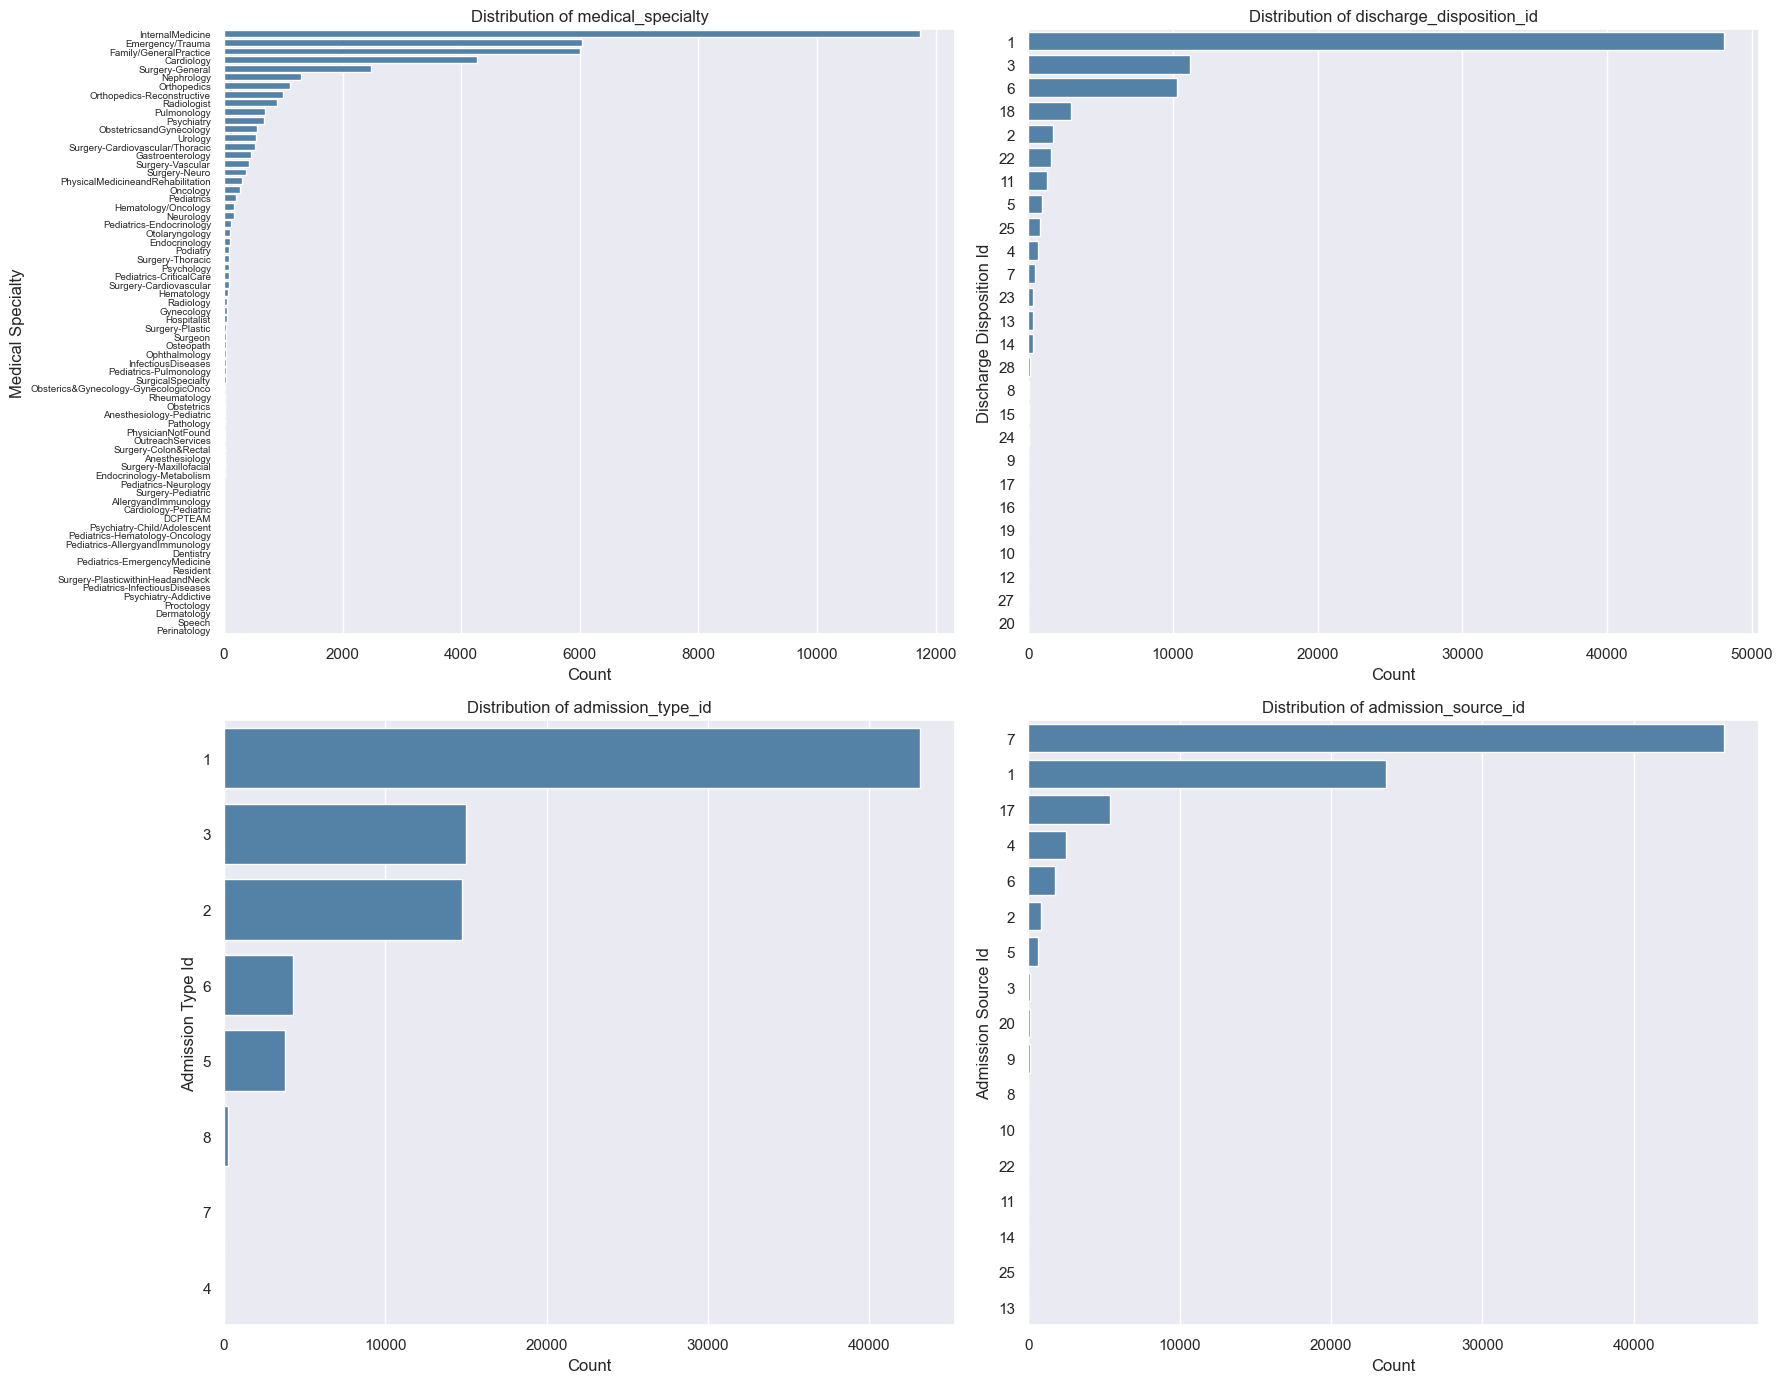



Observation:
- In addition to the high cardinality issue in `medical_specialty`, all these features have imbalanced distribution of labels.
- Many of their labels share similar medical or operational implications and thus can be reduced into common groups.


Decision:
- Group the labels based on the following mapping dictionaries.
- Perform one-hot encoding after grouping.




In [10]:
print('Medical specialty and operations (`medical_specialty`, `discharge_disposition_id`, `admission_type_id`, and `admission_source_id`)')
print('\n')

# Plot histogram of medical specialties and operations
print('Plot histograms of medical specialties and operations:')

columns = [
    "medical_specialty",
    "discharge_disposition_id",
    "admission_type_id",
    "admission_source_id"
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, column in zip(axes.flat, columns):
    order = X_train[column].value_counts().index

    sns.countplot(
        data=X_train,
        y=column,
        order=order,
        ax=ax,
        color="steelblue"
    )

    if column == "medical_specialty":
        ax.tick_params(axis="y", labelsize=7)

    ax.set(
        title=f"Distribution of {column}",
        xlabel="Count",
        ylabel=column.replace("_", " ").title()
    )

plt.tight_layout()
plt.show()
print('\n')

print('Observation:')
print(f'- In addition to the high cardinality issue in `medical_specialty`, all these features have imbalanced distribution of labels.')
print('- Many of their labels share similar medical or operational implications and thus can be reduced into common groups.')
print('\n')

print('Decision:')
print('- Group the labels based on the following mapping dictionaries.')
print('- Perform one-hot encoding after grouping.')
print('\n')

In [11]:
print('Grouping - `medical_specialty`')
print(
'''
    {
        # Missing / Unknown
        '?'                                   : 'Unknown',
        'PhysicianNotFound'                   : 'Unknown',

        # General Medicine & Primary Care
        'InternalMedicine'                    : 'General_Medicine',
        'Family/GeneralPractice'              : 'General_Medicine',
        'Hospitalist'                         : 'General_Medicine',
        'Resident'                            : 'General_Medicine',
        'Osteopath'                           : 'General_Medicine',

        # Emergency
        'Emergency/Trauma'                    : 'Emergency_Acute',

        # Cardiology & Vascular
        'Cardiology'                          : 'Cardiology_Vascular',
        'Surgery-Cardiovascular/Thoracic'     : 'Cardiology_Vascular',
        'Surgery-Vascular'                    : 'Cardiology_Vascular',
        'Surgery-Cardiovascular'              : 'Cardiology_Vascular',
        'Surgery-Thoracic'                    : 'Cardiology_Vascular',

        # Endocrine, Renal & Internal Specialties
        'Nephrology'                          : 'Endocrine_Renal_Internal',
        'Pulmonology'                         : 'Endocrine_Renal_Internal',
        'Gastroenterology'                    : 'Endocrine_Renal_Internal',
        'Oncology'                            : 'Endocrine_Renal_Internal',
        'Hematology/Oncology'                 : 'Endocrine_Renal_Internal',
        'Neurology'                           : 'Endocrine_Renal_Internal',
        'Endocrinology'                       : 'Endocrine_Renal_Internal',
        'Hematology'                          : 'Endocrine_Renal_Internal',
        'InfectiousDiseases'                  : 'Endocrine_Renal_Internal',
        'Rheumatology'                        : 'Endocrine_Renal_Internal',
        'Pathology'                           : 'Endocrine_Renal_Internal',
        'Endocrinology-Metabolism'            : 'Endocrine_Renal_Internal',
        'AllergyandImmunology'                : 'Endocrine_Renal_Internal',
        'Neurophysiology'                     : 'Endocrine_Renal_Internal',

        # General & Specialized Surgery
        'Surgery-General'                     : 'Surgery',
        'Surgeon'                             : 'Surgery',
        'SurgicalSpecialty'                   : 'Surgery',
        'Surgery-Neuro'                       : 'Surgery',
        'Otolaryngology'                      : 'Surgery',
        'Surgery-Plastic'                     : 'Surgery',
        'Surgery-Colon&Rectal'                : 'Surgery',
        'Surgery-Maxillofacial'               : 'Surgery',
        'Surgery-Pediatric'                   : 'Surgery',
        'Surgery-PlasticwithinHeadandNeck'    : 'Surgery',
        'Proctology'                          : 'Surgery',

        # Orthopedics & Rehab (Crucial for Diabetic Podiatry)
        'Orthopedics'                         : 'Orthopedics_Rehab',
        'Orthopedics-Reconstructive'          : 'Orthopedics_Rehab',
        'PhysicalMedicineandRehabilitation'   : 'Orthopedics_Rehab',
        'Podiatry'                            : 'Orthopedics_Rehab',
        'SportsMedicine'                      : 'Orthopedics_Rehab',

        # Radiology
        'Radiologist'                         : 'Radiology_Imaging',
        'Radiology'                           : 'Radiology_Imaging',

        # Mental Health
        'Psychiatry'                          : 'Mental_Health',
        'Psychology'                          : 'Mental_Health',
        'Psychiatry-Child/Adolescent'         : 'Mental_Health',
        'Psychiatry-Addictive'                : 'Mental_Health',
        'Speech'                              : 'Mental_Health',

        # OB/GYN
        'ObstetricsandGynecology'             : 'OB_GYN',
        'Gynecology'                          : 'OB_GYN',
        'Obsterics&Gynecology-GynecologicOnco': 'OB_GYN',
        'Obstetrics'                          : 'OB_GYN',
        'Perinatology'                        : 'OB_GYN',

        # Pediatrics
        'Pediatrics'                          : 'Pediatrics',
        'Pediatrics-Endocrinology'            : 'Pediatrics',
        'Pediatrics-CriticalCare'             : 'Pediatrics',
        'Pediatrics-Pulmonology'              : 'Pediatrics',
        'Anesthesiology-Pediatric'            : 'Pediatrics',
        'Pediatrics-Neurology'                : 'Pediatrics',
        'Cardiology-Pediatric'                : 'Pediatrics',
        'Pediatrics-Hematology-Oncology'      : 'Pediatrics',
        'Pediatrics-EmergencyMedicine'        : 'Pediatrics',
        'Pediatrics-AllergyandImmunology'     : 'Pediatrics',
        'Pediatrics-InfectiousDiseases'       : 'Pediatrics',

        # Other Minor Support Services
        'Urology'                             : 'Other',
        'Ophthalmology'                       : 'Other',
        'Anesthesiology'                      : 'Other',
        'OutreachServices'                    : 'Other',
        'DCPTEAM'                             : 'Other',
        'Dentistry'                           : 'Other',
        'Dermatology'                         : 'Other',
    }
'''
)
print('\n')

Grouping - `medical_specialty`

    {
        # Missing / Unknown
        '?'                                   : 'Unknown',
        'PhysicianNotFound'                   : 'Unknown',

        # General Medicine & Primary Care
        'InternalMedicine'                    : 'General_Medicine',
        'Family/GeneralPractice'              : 'General_Medicine',
        'Hospitalist'                         : 'General_Medicine',
        'Resident'                            : 'General_Medicine',
        'Osteopath'                           : 'General_Medicine',

        # Emergency
        'Emergency/Trauma'                    : 'Emergency_Acute',

        # Cardiology & Vascular
        'Cardiology'                          : 'Cardiology_Vascular',
        'Surgery-Cardiovascular/Thoracic'     : 'Cardiology_Vascular',
        'Surgery-Vascular'                    : 'Cardiology_Vascular',
        'Surgery-Cardiovascular'              : 'Cardiology_Vascular',
        'Surgery-Thoracic'  

In [12]:
print('Grouping - `admission_type_id`')
print(
'''
    {
        '1': 'Emergency_Acute' , # Emergency
        '2': 'Emergency_Acute' , # Urgent
        '3': 'Elective_Planned', # Elective
        '4': 'Other_LowVolume' , # Newborn
        '5': 'Unknown'         , # Not Available
        '6': 'Unknown'         , # NULL
        '7': 'Emergency_Acute' , # Trauma Center
        '8': 'Unknown'         , # Not Mapped
    }
'''
)
print('\n')

Grouping - `admission_type_id`

    {
        '1': 'Emergency_Acute' , # Emergency
        '2': 'Emergency_Acute' , # Urgent
        '3': 'Elective_Planned', # Elective
        '4': 'Other_LowVolume' , # Newborn
        '5': 'Unknown'         , # Not Available
        '6': 'Unknown'         , # NULL
        '7': 'Emergency_Acute' , # Trauma Center
        '8': 'Unknown'         , # Not Mapped
    }





In [13]:
print('Grouping - `admission_source_id`')
print(
'''
    {
        # Emergency Room
        '7' : 'Emergency_Room',

        # Referrals
        '1' : 'Referral',
        '2' : 'Referral',
        '3' : 'Referral',

        # Transfers from other medical frameworks
        '4' : 'Transfer_From_Facility',
        '5' : 'Transfer_From_Facility',
        '6' : 'Transfer_From_Facility',
        '10': 'Transfer_From_Facility',
        '22': 'Transfer_From_Facility',
        '25': 'Transfer_From_Facility',

        # Missing data flags or rare legal/court admissions
        '8' : 'Unknown,
        '9' : 'Unknown,
        '11': 'Unknown,
        '13': 'Unknown,
        '14': 'Unknown,
        '17': 'Unknown,
        '20': 'Unknown
    }
'''
)
print('\n')

Grouping - `admission_source_id`

    {
        # Emergency Room
        '7' : 'Emergency_Room',

        # Referrals
        '1' : 'Referral',
        '2' : 'Referral',
        '3' : 'Referral',

        # Transfers from other medical frameworks
        '4' : 'Transfer_From_Facility',
        '5' : 'Transfer_From_Facility',
        '6' : 'Transfer_From_Facility',
        '10': 'Transfer_From_Facility',
        '22': 'Transfer_From_Facility',
        '25': 'Transfer_From_Facility',

        # Missing data flags or rare legal/court admissions
        '8' : 'Unknown,
        '9' : 'Unknown,
        '11': 'Unknown,
        '13': 'Unknown,
        '14': 'Unknown,
        '17': 'Unknown,
        '20': 'Unknown
    }





In [14]:
print('Grouping - `discharge_disposition_id`')
print(
'''
    {
        # Discharged Home
        '1' : 'Home',
        '6' : 'Home',
        '8' : 'Home',
        '13': 'Home',
        '14': 'Home',

        # Transferred to alternative healthcare facilities
        '2' : 'Transferred_Facility',
        '3' : 'Transferred_Facility',
        '4' : 'Transferred_Facility',
        '5' : 'Transferred_Facility',
        '22': 'Transferred_Facility',
        '23': 'Transferred_Facility',
        '24': 'Transferred_Facility',
        '28': 'Transferred_Facility',

        # Left Against Medical Advice / Missing / Other
        '7' : 'Unknown',
        '9' : 'Unknown',
        '10': 'Unknown',
        '12': 'Unknown',
        '15': 'Unknown',
        '16': 'Unknown',
        '17': 'Unknown',
        '18': 'Unknown',
        '25': 'Unknown',
        '27': 'Unknown',

        # Patient expired or is in hospice (cannot be readmitted)
        '11': 'Expired_Hospice',
        '19': 'Expired_Hospice',
        '20': 'Expired_Hospice',
    }
'''
)
print('\n')

Grouping - `discharge_disposition_id`

    {
        # Discharged Home
        '1' : 'Home',
        '6' : 'Home',
        '8' : 'Home',
        '13': 'Home',
        '14': 'Home',

        # Transferred to alternative healthcare facilities
        '2' : 'Transferred_Facility',
        '3' : 'Transferred_Facility',
        '4' : 'Transferred_Facility',
        '5' : 'Transferred_Facility',
        '22': 'Transferred_Facility',
        '23': 'Transferred_Facility',
        '24': 'Transferred_Facility',
        '28': 'Transferred_Facility',

        # Left Against Medical Advice / Missing / Other
        '7' : 'Unknown',
        '9' : 'Unknown',
        '10': 'Unknown',
        '12': 'Unknown',
        '15': 'Unknown',
        '16': 'Unknown',
        '17': 'Unknown',
        '18': 'Unknown',
        '25': 'Unknown',
        '27': 'Unknown',

        # Patient expired or is in hospice (cannot be readmitted)
        '11': 'Expired_Hospice',
        '19': 'Expired_Hospice',
        '20': '

Plot histograms after grouping:


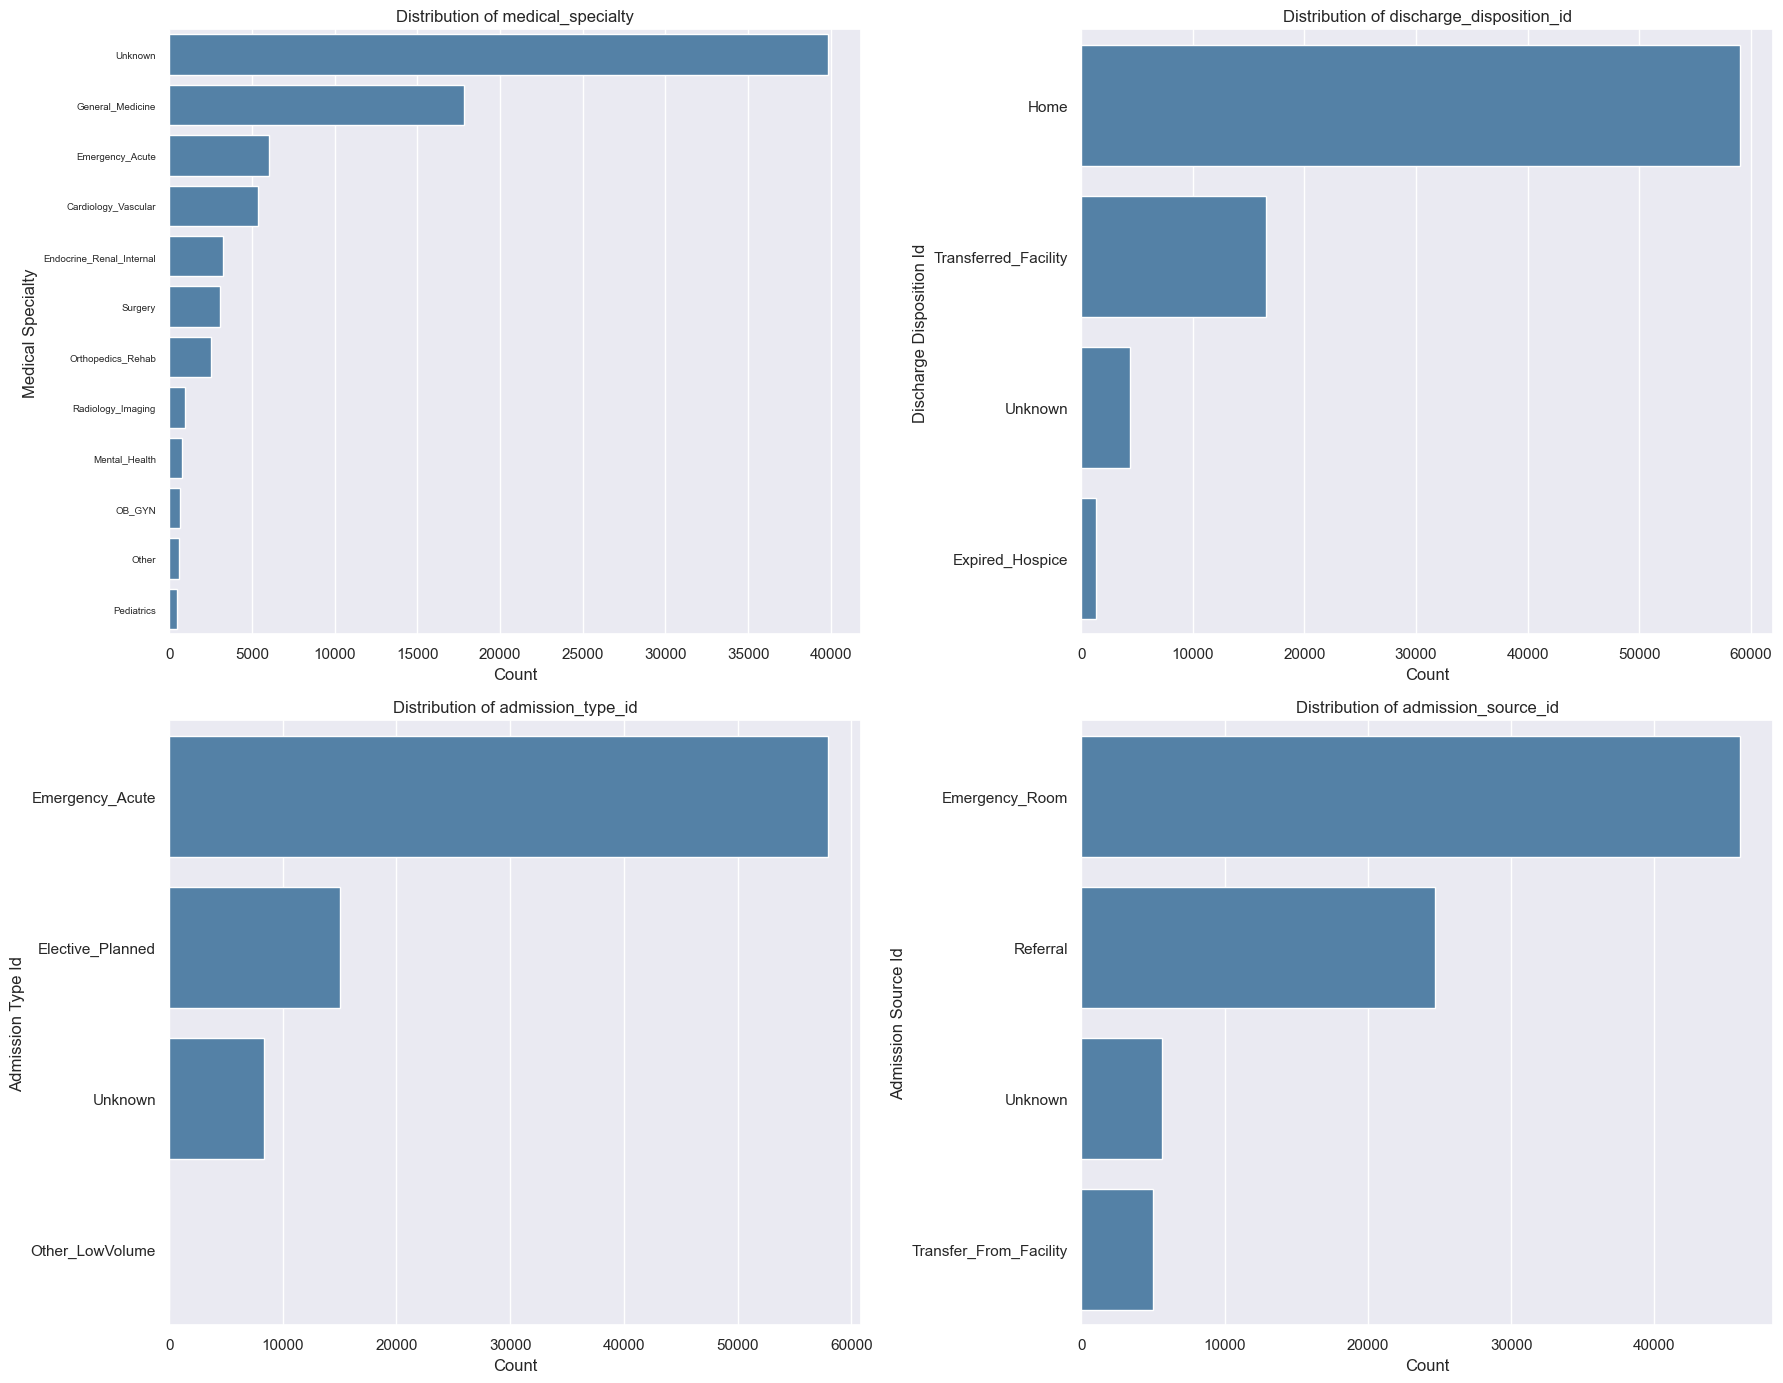

In [15]:
X_train_adj = MedicalSpecialtyGrouper().fit_transform(X_train)
X_train_adj = AdmissionTypeIdGrouper().fit_transform(X_train_adj)
X_train_adj = AdmissionSourceIdGrouper().fit_transform(X_train_adj)
X_train_adj = DischargeDispositionIdGrouper().fit_transform(X_train_adj)

print('Plot histograms after grouping:')
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, column in zip(axes.flat, columns):
    order = X_train_adj[column].value_counts().index

    sns.countplot(
        data=X_train_adj,
        y=column,
        order=order,
        ax=ax,
        color="steelblue"
    )

    if column == "medical_specialty":
        ax.tick_params(axis="y", labelsize=7)

    ax.set(
        title=f"Distribution of {column}",
        xlabel="Count",
        ylabel=column.replace("_", " ").title()
    )

plt.tight_layout()
plt.show()
print('\n')

### Prescription data analysis

Prescription data analysis


Plot proportion of prescription / medication labels:


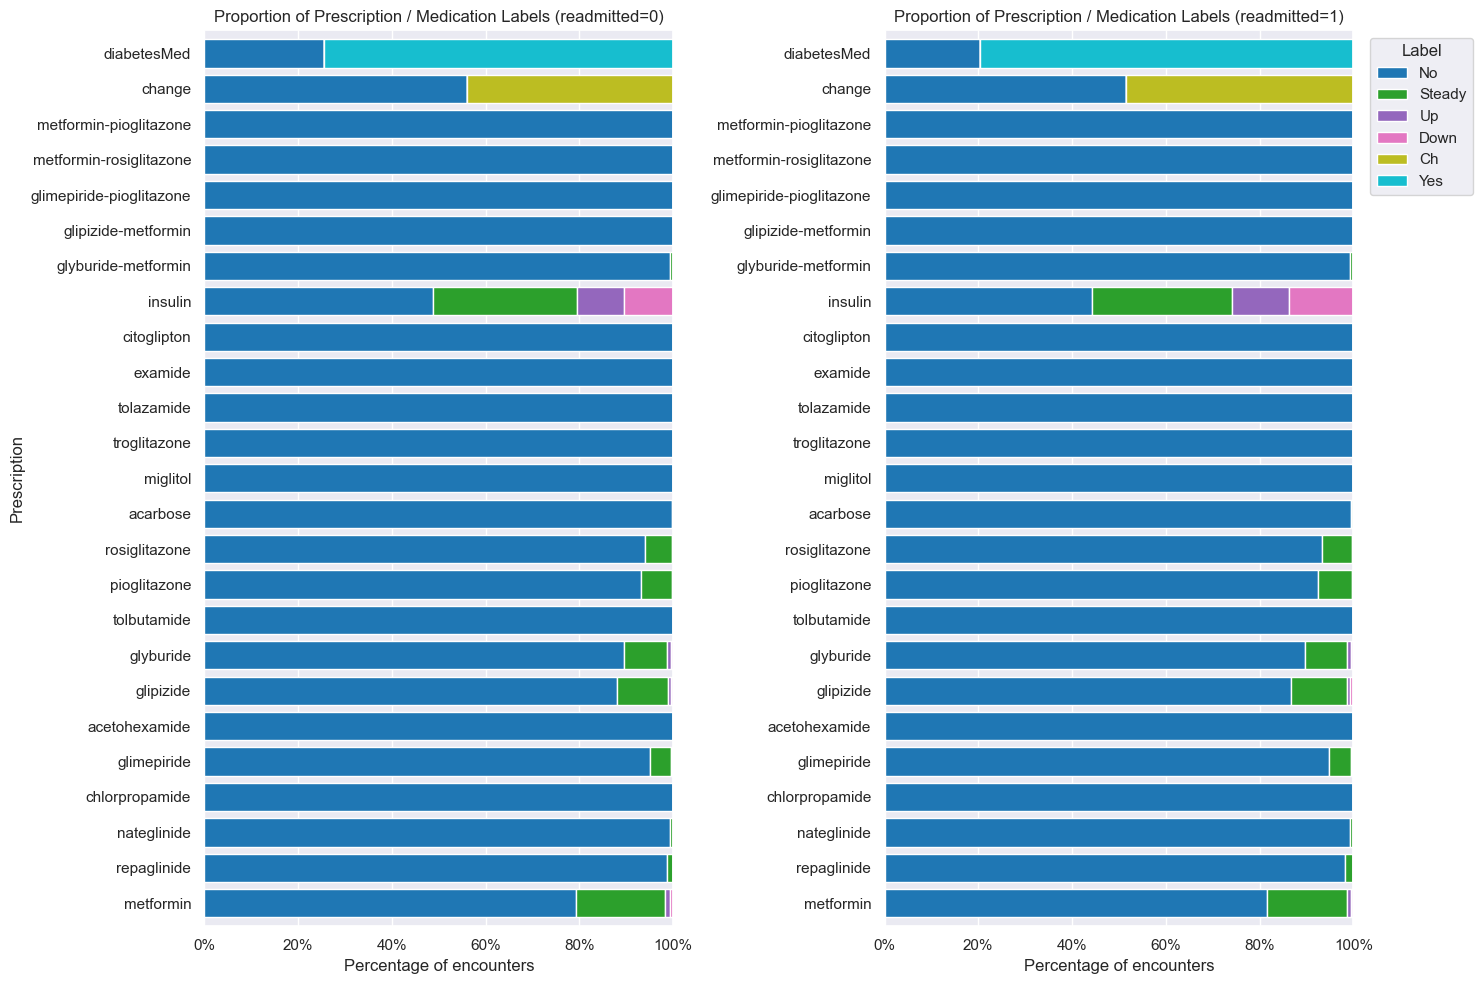



Association analysis:
                        item  non_no_count  non_no_pct        chi2  \
0                    examide             0    0.000000    0.000000   
1                citoglipton             0    0.000000    0.000000   
2   glimepiride-pioglitazone             0    0.000000    0.000000   
3     metformin-pioglitazone             0    0.000000    0.000000   
4              acetohexamide             1    0.000012    0.006481   
5    metformin-rosiglitazone             2    0.000025    0.354679   
6               troglitazone             3    0.000037    0.019444   
7        glipizide-metformin             9    0.000111    0.828811   
8                tolbutamide            21    0.000258    0.256885   
9                 tolazamide            30    0.000369    1.458682   
10                  miglitol            36    0.000443    7.750763   
11            chlorpropamide            60    0.000738    4.252746   
12                  acarbose           248    0.003050   26.094767

In [21]:
print('Prescription data analysis')
print('\n')

col_prescription = [
    "metformin"              , "repaglinide"           , "nateglinide",
    "chlorpropamide"         , "glimepiride"           , "acetohexamide",
    "glipizide"              , "glyburide"             , "tolbutamide",
    "pioglitazone"           , "rosiglitazone"         , "acarbose",
    "miglitol"               , "troglitazone"          , "tolazamide",
    "examide"                , "citoglipton"           , "insulin",
    "glyburide-metformin"    , "glipizide-metformin"   , "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone", "change",
    "diabetesMed"
]

# Count each label and normalize within each column
df_proportions_0 = X_train[col_prescription].loc[y_train == 0].apply(lambda col: col.fillna("Unknown").value_counts(normalize=True)).T.fillna(0)
df_proportions_1 = X_train[col_prescription].loc[y_train == 1].apply(lambda col: col.fillna("Unknown").value_counts(normalize=True)).T.fillna(0)

# Optional: define a consistent label order
label_order_0 = [label for label in ["No", "Steady", "Up", "Down", "Ch", "Yes", 'Unknown'] if label in df_proportions_0.columns]
df_proportions_0 = df_proportions_0[label_order_0]
label_order_1 = [label for label in ["No", "Steady", "Up", "Down", "Ch", "Yes", 'Unknown'] if label in df_proportions_1.columns]
df_proportions_1 = df_proportions_1[label_order_1]

# Plot proportion of prescription labels
print('Plot proportion of prescription / medication labels:')

fig, axes = plt.subplots(1, 2, figsize=(38, 36))

df_proportions_0.plot(
    kind="barh",
    stacked=True,
    figsize=(13, 12),
    width=0.8,
    colormap="tab10",
    ax=axes[0]
)
axes[0].set_xlim(0, 1)
axes[0].xaxis.set_major_formatter(PercentFormatter(xmax=1))
axes[0].set(
    title="Proportion of Prescription / Medication Labels (readmitted=0)",
    xlabel="Percentage of encounters",
    ylabel="Prescription"
)
axes[0].legend().remove()
df_proportions_1.plot(
    kind="barh",
    stacked=True,
    figsize=(15, 10),
    width=0.8,
    colormap="tab10",
    ax=axes[1]
)
axes[1].set_xlim(0, 1)
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1))
axes[1].set(
    title="Proportion of Prescription / Medication Labels (readmitted=1)",
    xlabel="Percentage of encounters",
)
axes[1].legend(
    title="Label",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()
print('\n')

# Association analysis
print('Association analysis:')

from scipy.stats import chi2_contingency

def categorical_association(df, col, target="readmitted"):
    table = pd.crosstab(df[col], df[target])
    chi2, p_value, dof, expected = chi2_contingency(table)

    return {
        "item": col,
        "non_no_count": df[col].ne("No").sum(),
        "non_no_pct": df[col].ne("No").mean(),
        "chi2": chi2,
        "p_value": p_value,
        "min_expected_count": expected.min()
    }

df_pres = X_train.copy()
df_pres["readmitted"] = y_train
df_chi = (pd.DataFrame([categorical_association(df_pres, col) for col in col_prescription])
               .sort_values(['non_no_pct', 'p_value']).reset_index(drop=True))
print(df_chi)
print('\n')

print('Observation:')
print(f'- Many prescription related features contain significant amount of "No" labels (i.e. the drug was not prescribed).')
print('- From the chi-square test results, all drugs with >99.9% "No" (non_no_pct < 0.001) labels have insignificant association with the target variable `readmitted`.')
print(f'- Only {", ".join([f'`{x}`' for x in df_chi.loc[df_chi['p_value'] < 0.05, "item"].tolist()])} are significant at 5%.')
print('\n')

print('Decision:')
print(f'- Drop the drugs with only "No" label (not prescribed). These include {', '.join([f'`{x}`' for x in np.asarray(col_prescription)[(X_train[col_prescription] == 'No').all()].tolist()])}.')
print('- Although many drugs are rarely prescribed or have insignificant individual association with the target variable `readmitted`, '
      'we cannot rule out any cross association or non-linear effects due to a combination of prescriptions. '
      'Hence, we need to keep all other prescriptions and use advanced approach (i.e. ensemble based method) to perform feature selections.')
print('- Perform one-hot encoding for the remaining prescription features.')
print('\n')

### Numerical data analysis (bivariate)

Numerical data analysis (bivariate)


Plot pair plots for numerical features


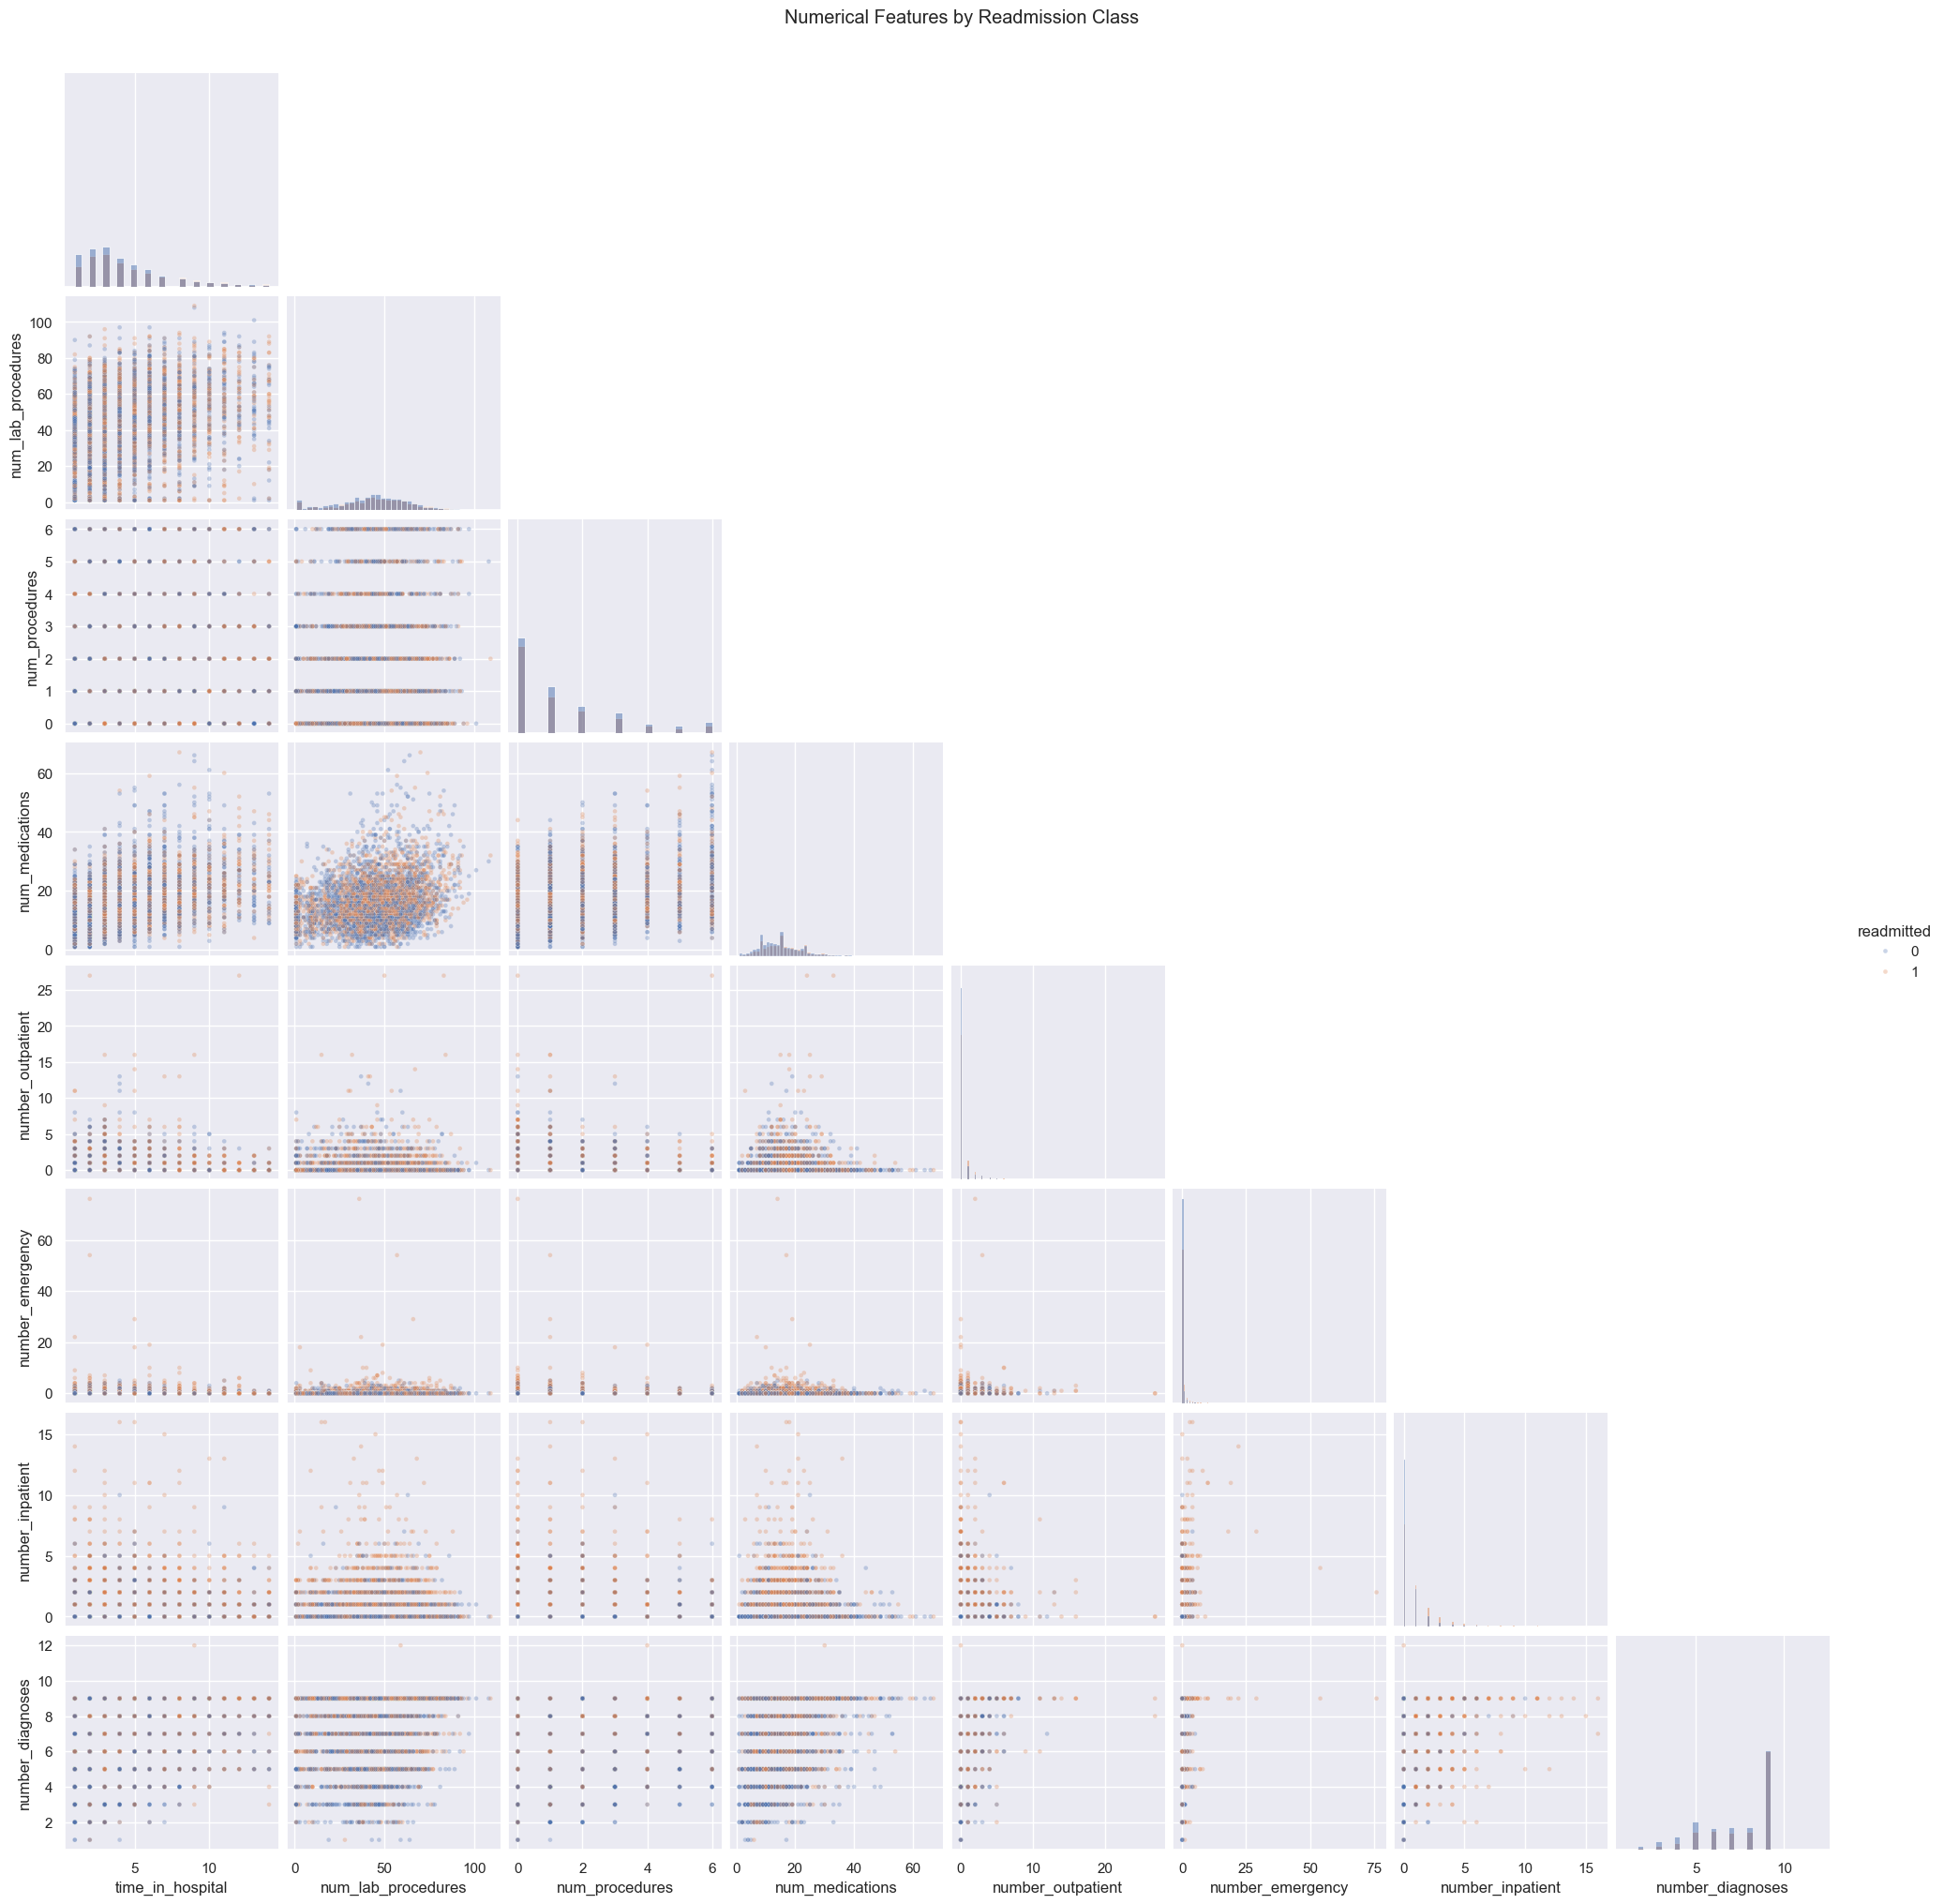



Observation:
- All numerical features are discrete and most of them suffer from high skewness (except for `num_lab_procedures` and `number_diagnosis`) with weak or no normality.
- None of them demonstrate high correlation among each other.
- No significant issues of outliers despite of high sparsity.


Decision:
- Perform standardization on numerical features.




In [17]:
print('Numerical data analysis (bivariate)')
print('\n')

print('Plot pair plots for numerical features')
plot_df = X_train[col_int].copy()
plot_df["readmitted"] = y_train.to_numpy()
plot_sample = plot_df.dropna().sample(
    n=min(5000, len(plot_df)),
    random_state=42
)
g = sns.pairplot(
    plot_sample,
    vars=col_int,
    hue="readmitted",
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.3, "s": 12}
)
g.fig.suptitle(
    "Numerical Features by Readmission Class",
    y=1.02
)
plt.show()
print('\n')

print('Observation:')
print(f'- All numerical features are discrete and most of them suffer from high skewness (except for `num_lab_procedures` and `number_diagnosis`) with weak or no normality.')
print('- None of them demonstrate high correlation among each other.')
print(f'- No significant issues of outliers despite of high sparsity.')
print('\n')

print('Decision:')
print('- Perform standardization on numerical features.')
print('\n')